In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("qm9.csv")
df_small = df.iloc[:20000]

In [5]:
print(df_small.shape)
print(df_small.columns)
df_small.head()

(20000, 21)
Index(['mol_id', 'smiles', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap',
       'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom',
       'u298_atom', 'h298_atom', 'g298_atom'],
      dtype='object')


,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,C,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,N,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,...,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,O,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,...,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,C#C,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,C#N,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,...,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


In [6]:
cols = ['mol_id','smiles','mu','u0_atom','homo','lumo','gap']
df_exp = df_small[cols]
df_exp.to_csv("qm9_exp.csv", index=False)

In [7]:
df_exp = pd.read_csv("qm9_exp.csv")
print(df_exp.shape)
print(df_exp.columns)
df_exp.head()

(20000, 7)
Index(['mol_id', 'smiles', 'mu', 'u0_atom', 'homo', 'lumo', 'gap'], dtype='object')


,mol_id,smiles,mu,u0_atom,homo,lumo,gap
0,gdb_1,C,0.0000,-395.999595,-0.3877,0.1171,0.5048
1,gdb_2,N,1.6256,-276.861363,-0.2570,0.0829,0.3399
2,gdb_3,O,1.8511,-213.087624,-0.2928,0.0687,0.3615
3,gdb_4,C#C,0.0000,-385.501997,-0.2845,0.0506,0.3351
4,gdb_5,C#N,2.8937,-301.820534,-0.3604,0.0191,0.3796


In [8]:
df_exp.isnull().sum()

mol_id     0
smiles     0
mu         0
u0_atom    0
homo       0
lumo       0
gap        0
dtype: int64

In [11]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install rdkit-pypi

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 16.2 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/20.5 MB ? eta -:--:--
   --- ------------------------------------ 1.6/20.5 MB 16.8 MB/s eta 0:00:02
   --------------------------------- ------ 17.0/20.5 MB 59.7 MB/s eta 0:00:01
   ---------------------------------------- 20.5/20.5 MB 56.2 MB/s  0:00:00


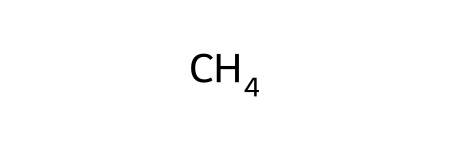

In [12]:
from rdkit import Chem
Chem.MolFromSmiles(df_exp['smiles'][0])

## random split

In [13]:
# molecular fingerprint
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros(2048)
    AllChem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [14]:
fp = smiles_to_fp(df_exp['smiles'][0])
print(fp.shape)
print(fp[:20])

(2048,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
# EX -1
X = np.array([smiles_to_fp(s) for s in df_exp['smiles']])
print(X.shape)
y = df_exp['mu'].values
print(y.shape)

(20000, 2048)
(20000,)


In [27]:
targets = ['mu', 'u0_atom', 'homo', 'lumo', 'gap']
results = []

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, idx_train, idx_test = train_test_split(
    X, np.arange(len(X)), test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import kendalltau
for t in targets:
    print(f"exp_{t}")
    y = df_exp[t].values
    y_train = y[idx_train]
    y_test  = y[idx_test]
    
    # ---- Linear ----
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    y_pred_lin = lin.predict(X_test)
    
    lin_mae   = mean_absolute_error(y_test, y_pred_lin)
    lin_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_lin))
    lin_r2    = r2_score(y_test, y_pred_lin)
    lin_tau,_ = kendalltau(y_test, y_pred_lin)
    
    # ---- Random Forest ----
    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    rf_mae   = mean_absolute_error(y_test, y_pred_rf)
    rf_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    rf_r2    = r2_score(y_test, y_pred_rf)
    rf_tau,_ = kendalltau(y_test, y_pred_rf)
    
    results.append([
        t,
        lin_mae, lin_rmse, lin_r2, lin_tau,
        rf_mae,  rf_rmse,  rf_r2,  rf_tau
    ])


exp_mu
exp_u0_atom
exp_homo
exp_lumo
exp_gap


In [30]:
df_results = pd.DataFrame(
    results,
    columns=[
        'Target',
        'Linear_MAE','Linear_RMSE','Linear_R2','Linear_Kendall',
        'RF_MAE','RF_RMSE','RF_R2','RF_Kendall'
    ]
)

print(df_results)

    Target  Linear_MAE  Linear_RMSE  Linear_R2  Linear_Kendall     RF_MAE  \
0       mu    0.761775     1.022510   0.531398        0.541875   0.573319   
1  u0_atom   82.266634   110.106228   0.761637        0.694614  92.490937   
2     homo    0.008753     0.011959   0.722463        0.635474   0.007983   
3     lumo    0.012903     0.016726   0.871752        0.772840   0.008485   
4      gap    0.015007     0.019701   0.823622        0.749688   0.009570   

      RF_RMSE     RF_R2  RF_Kendall  
0    0.861294  0.667515    0.645475  
1  127.866974  0.678537    0.641096  
2    0.011503  0.743222    0.655991  
3    0.012673  0.926380    0.841192  
4    0.014225  0.908043    0.831802  


In [34]:
norm_results = df_results.copy()

for t in df_results['Target']:
    std = df_exp[t].std()
    norm_results.loc[norm_results['Target']==t, 'Linear_MAE'] /= std
    norm_results.loc[norm_results['Target']==t, 'RF_MAE'] /= std

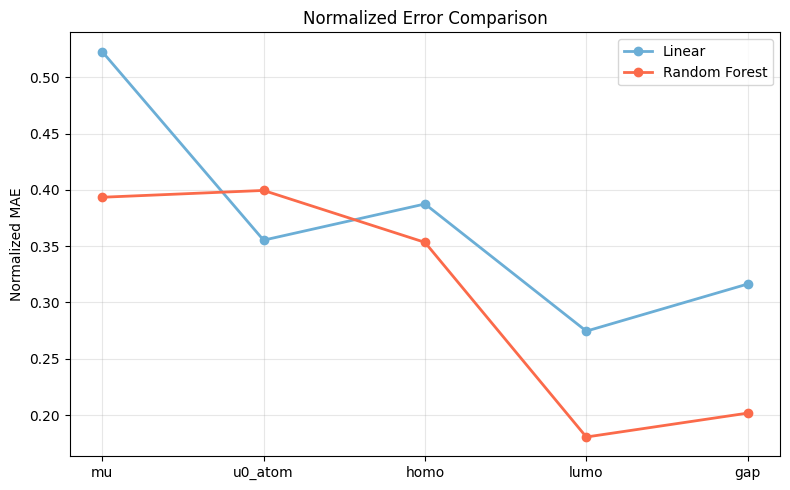

In [38]:
plt.figure(figsize=(8,5))

plt.plot(norm_results['Target'],
         norm_results['Linear_MAE'],
         marker='o',
         linewidth=2,
         color='#6BAED6',
         label='Linear')

plt.plot(norm_results['Target'],
         norm_results['RF_MAE'],
         marker='o',
         linewidth=2,
         color='#FB6A4A',
         label='Random Forest')

plt.ylabel("Normalized MAE")
plt.title("Normalized Error Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

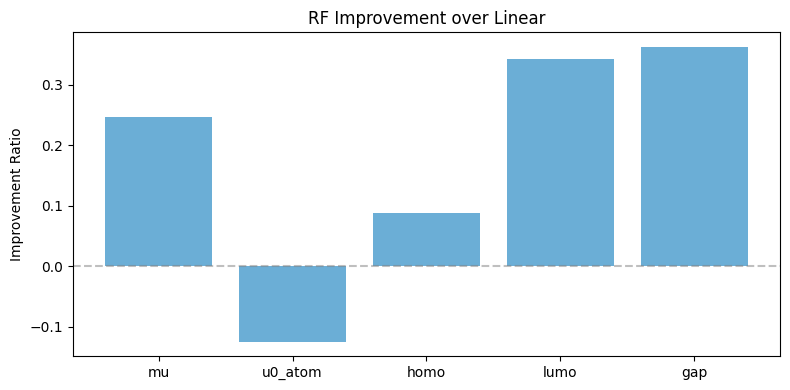

In [41]:
plt.figure(figsize=(8,4))

plt.bar(df_results['Target'],
        improvement,
        color='#6BAED6')

plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.ylabel("Improvement Ratio")
plt.title("RF Improvement over Linear")
plt.tight_layout()
plt.show()

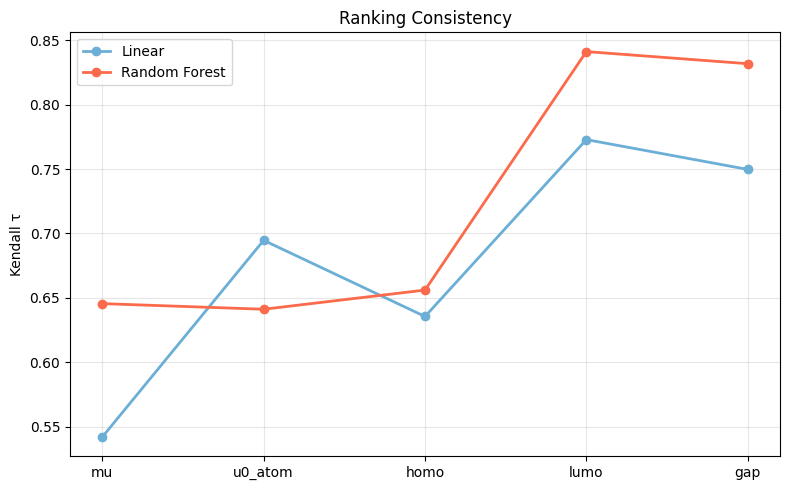

In [40]:
plt.figure(figsize=(8,5))

plt.plot(df_results['Target'],
         df_results['Linear_Kendall'],
         marker='o',
         linewidth=2,
         color='#6BAED6',
         label='Linear')

plt.plot(df_results['Target'],
         df_results['RF_Kendall'],
         marker='o',
         linewidth=2,
         color='#FB6A4A',
         label='Random Forest')

plt.ylabel("Kendall τ")
plt.title("Ranking Consistency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Scaffold Split

In [42]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

df_exp['scaffold'] = df_exp['smiles'].apply(get_scaffold)

In [43]:
scaffold_groups = df_exp.groupby('scaffold').indices
scaffolds = list(scaffold_groups.keys())
np.random.seed(42)
np.random.shuffle(scaffolds)

train_idx = []
test_idx = []

n_total = len(df_exp)
n_train_target = int(0.8 * n_total)

for scaffold in scaffolds:
    indices = scaffold_groups[scaffold]
    if len(train_idx) + len(indices) <= n_train_target:
        train_idx.extend(indices)
    else:
        test_idx.extend(indices)

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

print(len(train_idx), len(test_idx))

16000 4000


In [44]:
X_train = X[train_idx]
X_test  = X[test_idx]

In [45]:
# calculate the au numbers
df_exp['num_atoms'] = df_exp['smiles'].apply(
    lambda s: Chem.MolFromSmiles(s).GetNumAtoms()
)


In [48]:
targets = ['mu','u0_atom','homo','lumo','gap']

scaffold_results = {}
summary_results = []

X_train = X[train_idx]
X_test  = X[test_idx]

for t in targets:
    
    y = df_exp[t].values
    y_train = y[train_idx]
    y_test  = y[test_idx]
    
    scaffold_results[t] = {}
    
    lin = LinearRegression()
    lin.fit(X_train, y_train)
    y_pred_lin = lin.predict(X_test)
    
    lin_mae   = mean_absolute_error(y_test, y_pred_lin)
    lin_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_lin))
    lin_r2    = r2_score(y_test, y_pred_lin)
    lin_tau,_ = kendalltau(y_test, y_pred_lin)
    
    scaffold_results[t]['Linear'] = {
        "y_test": y_test,
        "y_pred": y_pred_lin,
        "errors": np.abs(y_test - y_pred_lin),
        "num_atoms": df_exp.iloc[test_idx]['num_atoms'].values
    }
    
    rf = RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    
    rf_mae   = mean_absolute_error(y_test, y_pred_rf)
    rf_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    rf_r2    = r2_score(y_test, y_pred_rf)
    rf_tau,_ = kendalltau(y_test, y_pred_rf)
    
    scaffold_results[t]['RF'] = {
        "y_test": y_test,
        "y_pred": y_pred_rf,
        "errors": np.abs(y_test - y_pred_rf),
        "num_atoms": df_exp.iloc[test_idx]['num_atoms'].values
    }
    
    summary_results.append([
        t,
        lin_mae, lin_rmse, lin_r2, lin_tau,
        rf_mae, rf_rmse, rf_r2, rf_tau
    ])


In [49]:
df_scaffold_summary = pd.DataFrame(
    summary_results,
    columns=[
        'Target',
        'Linear_MAE','Linear_RMSE','Linear_R2','Linear_Kendall',
        'RF_MAE','RF_RMSE','RF_R2','RF_Kendall'
    ]
)

print(df_scaffold_summary)

    Target  Linear_MAE  Linear_RMSE  Linear_R2  Linear_Kendall     RF_MAE  \
0       mu    0.769638     1.003329   0.443464        0.490834   0.578532   
1  u0_atom   90.844567   117.998360   0.720193        0.659430  90.620694   
2     homo    0.009714     0.012598   0.517797        0.517098   0.009190   
3     lumo    0.014124     0.018344   0.845399        0.738411   0.009826   
4      gap    0.016097     0.020743   0.793697        0.720922   0.012160   

      RF_RMSE     RF_R2  RF_Kendall  
0    0.811007  0.636373    0.598844  
1  123.715953  0.692420    0.626196  
2    0.012356  0.536115    0.520537  
3    0.014465  0.903867    0.800480  
4    0.016402  0.871015    0.780337  


In [50]:
norm_scaffold = df_scaffold_summary.copy()

for t in norm_scaffold['Target']:
    std = df_exp[t].std()
    norm_scaffold.loc[norm_scaffold['Target']==t, 'Linear_MAE'] /= std
    norm_scaffold.loc[norm_scaffold['Target']==t, 'RF_MAE'] /= std

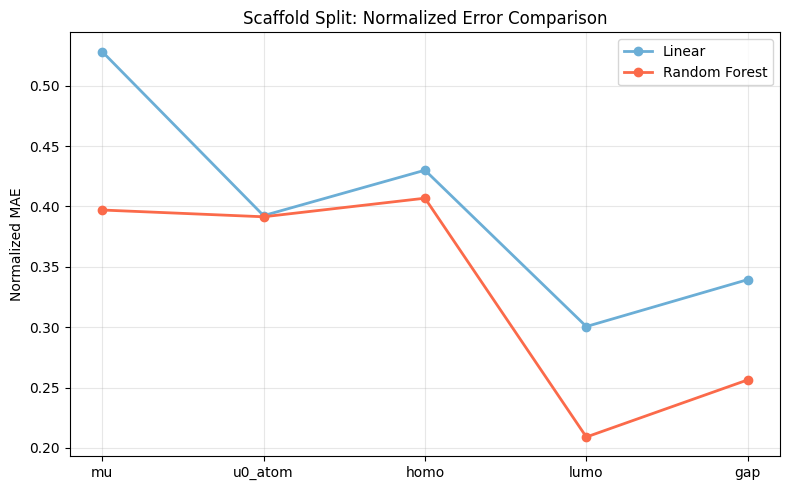

In [51]:
targets = norm_scaffold['Target']
x = np.arange(len(targets))

plt.figure(figsize=(8,5))

plt.plot(targets,
         norm_scaffold['Linear_MAE'],
         marker='o',
         linewidth=2,
         color='#6BAED6',
         label='Linear')

plt.plot(targets,
         norm_scaffold['RF_MAE'],
         marker='o',
         linewidth=2,
         color='#FB6A4A',
         label='Random Forest')

plt.ylabel("Normalized MAE")
plt.title("Scaffold Split: Normalized Error Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

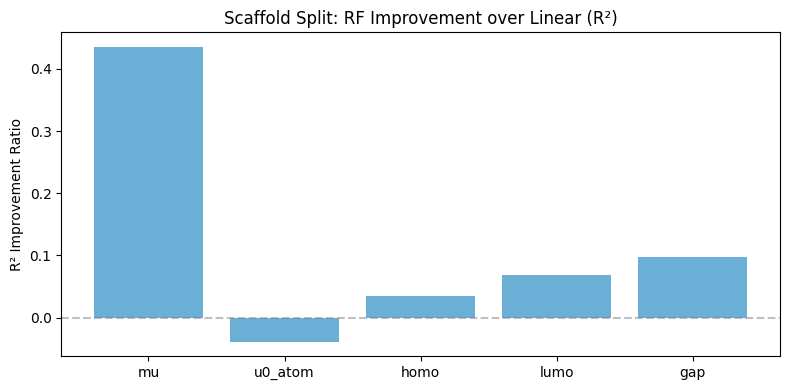

In [54]:
r2_improve = (
    (df_scaffold_summary['RF_R2'] -
     df_scaffold_summary['Linear_R2'])
    / df_scaffold_summary['Linear_R2']
)
plt.figure(figsize=(8,4))

plt.bar(df_scaffold_summary['Target'],
        r2_improve,
        color='#6BAED6')

plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.ylabel("R² Improvement Ratio")
plt.title("Scaffold Split: RF Improvement over Linear (R²)")
plt.tight_layout()
plt.show()

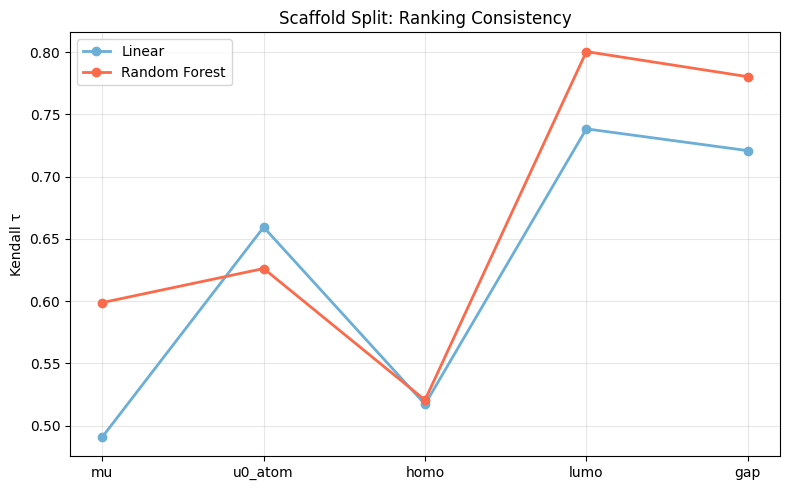

In [52]:
plt.figure(figsize=(8,5))

plt.plot(df_scaffold_summary['Target'],
         df_scaffold_summary['Linear_Kendall'],
         marker='o',
         linewidth=2,
         color='#6BAED6',
         label='Linear')

plt.plot(df_scaffold_summary['Target'],
         df_scaffold_summary['RF_Kendall'],
         marker='o',
         linewidth=2,
         color='#FB6A4A',
         label='Random Forest')

plt.ylabel("Kendall τ")
plt.title("Scaffold Split: Ranking Consistency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

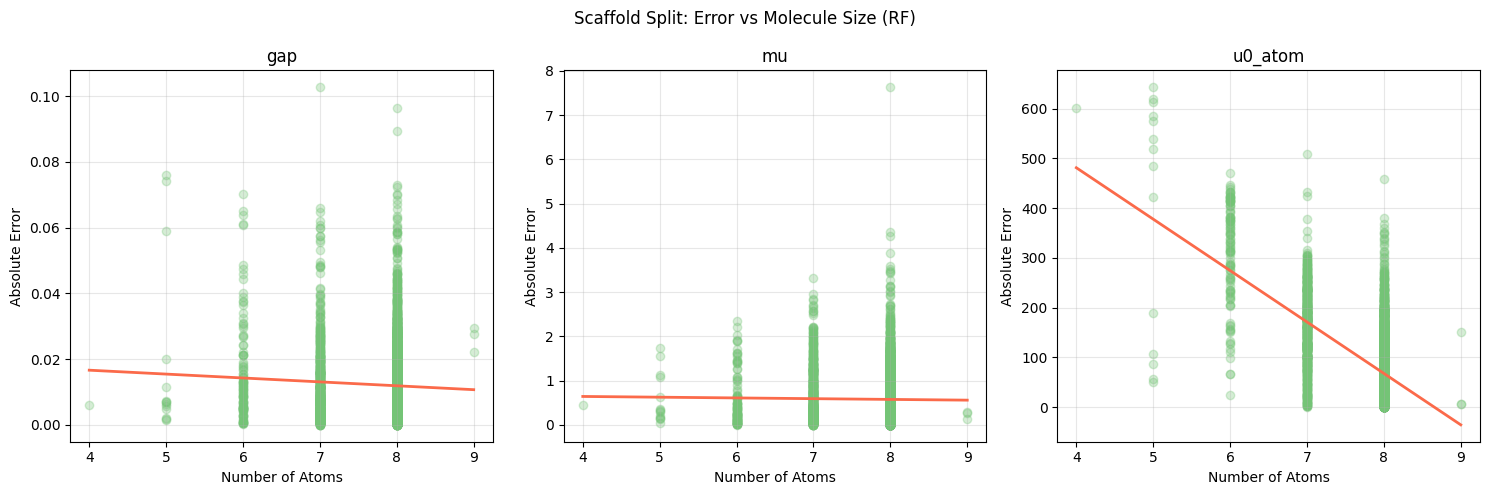

In [58]:
targets = ['gap', 'mu', 'u0_atom']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, t in enumerate(targets):
    
    data = scaffold_results[t]['RF']
    
    axes[i].scatter(data['num_atoms'],
                    data['errors'],
                    alpha=0.3,
                    color='#74C476')
    coef = np.polyfit(data['num_atoms'],
                      data['errors'], 1)
    poly = np.poly1d(coef)
    
    x_line = np.linspace(
        min(data['num_atoms']),
        max(data['num_atoms']), 100
    )
    
    axes[i].plot(x_line,
                 poly(x_line),
                 color='#FB6A4A',
                 linewidth=2)
    
    axes[i].set_title(t)
    axes[i].set_xlabel("Number of Atoms")
    axes[i].set_ylabel("Absolute Error")
    axes[i].grid(alpha=0.3)

plt.suptitle("Scaffold Split: Error vs Molecule Size (RF)")
plt.tight_layout()
plt.show()

In [59]:
r2_drop = (
    (df_results['RF_R2'] - df_scaffold_summary['RF_R2'])
    / df_results['RF_R2']
)

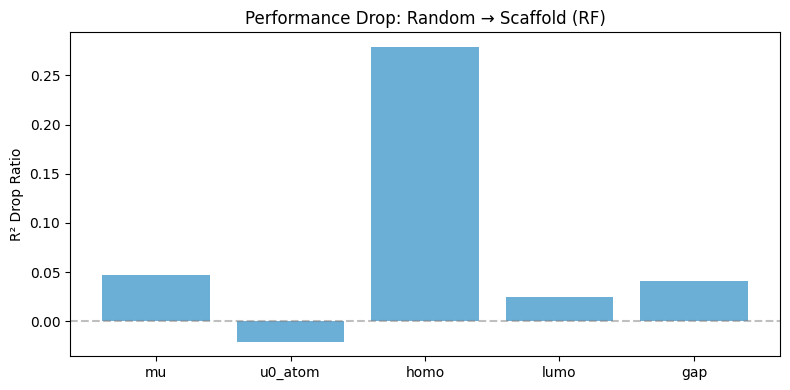

In [60]:

plt.figure(figsize=(8,4))

plt.bar(df_results['Target'],
        r2_drop,
        color='#6BAED6')

plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.ylabel("R² Drop Ratio")
plt.title("Performance Drop: Random → Scaffold (RF)")
plt.tight_layout()
plt.show()